# 04 — Zero-Shot Cross-Platform Transfer Experiment

**Input**: `post_features.csv` (post-level, 14 language-agnostic features, both labels)

**Outputs**:
- `results_summary.csv` — F1 / AUC / precision / recall for every experimental cell
- `per_feature_auc.csv` — per-feature within-platform AUC (for the transferability scatter)
- `transferability_scatter.png` — the headline figure

## Five experimental blocks

**Block 1: Within-domain TikTok baseline** — 5-fold CV on TikTok, label = `amp_prob_behavioral >= 0.5`. Establishes ceiling for the source domain.

**Block 2: Within-domain Pantip baseline** — 5-fold CV on Pantip, label = `is_sockpuppet`. Establishes ceiling for the target domain.

**Block 3: Zero-shot transfer (HEADLINE)** — train on all TikTok (`amp_prob_behavioral`), test on all Pantip (`is_sockpuppet`). No Pantip data seen at training time.

**Block 4: Ablation transfer** — same as Block 3 but using `amp_prob_full` as the TikTok label. Tests whether including Filipino-lexicon-triggered positives degrades or improves transfer.

**Block 5: Per-feature transferability scatter** — for each of the 14 features, fit single-feature logistic regression on each platform, plot TikTok AUC vs Pantip AUC. Points on the diagonal = transferable features; points off-diagonal = platform-specific.

## Classifiers (Lindsey's original five)

Naive Bayes (GaussianNB), Random Forest, LinearSVC, Decision Tree, MLP (DNN). Kept identical across all blocks so cells are directly comparable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    accuracy_score, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

IN_PATH    = 'post_features.csv'
RESULTS    = 'results_summary.csv'
PERFEAT    = 'per_feature_auc.csv'
SCATTER    = 'transferability_scatter.png'
RANDOM_SEED = 42

df = pd.read_csv(IN_PATH)
FEAT_COLS = ['n_chars','n_words','n_emoji','n_punct','emoji_density','punct_density',
             'is_short','is_long','is_emoji_heavy','max_token_repeat_ratio',
             'has_repeated_chars','hour_of_day','day_of_week','is_late_night']

tt = df[df['source']=='tiktok'].copy()
pt = df[df['source']=='pantip'].copy()

# Drop any rows with NaN in features
tt = tt.dropna(subset=FEAT_COLS)
pt = pt.dropna(subset=FEAT_COLS + ['is_sockpuppet'])

tt['y_behavioral'] = (tt['amp_prob_behavioral'] >= 0.5).astype(int)
tt['y_full']       = (tt['amp_prob_full']       >= 0.5).astype(int)
pt['y_sockpuppet'] = pt['is_sockpuppet'].astype(int)

print(f'TikTok: {len(tt):,} posts')
print(f'  y_behavioral positives: {tt["y_behavioral"].sum():,} ({tt["y_behavioral"].mean():.1%})')
print(f'  y_full positives:       {tt["y_full"].sum():,} ({tt["y_full"].mean():.1%})')
print(f'Pantip: {len(pt):,} posts')
print(f'  y_sockpuppet positives: {pt["y_sockpuppet"].sum():,} ({pt["y_sockpuppet"].mean():.1%})')

TikTok: 19,842 posts
  y_behavioral positives: 1,972 (9.9%)
  y_full positives:       4,498 (22.7%)
Pantip: 5,457 posts
  y_sockpuppet positives: 2,390 (43.8%)


## Classifier factory

All classifiers fit on a `StandardScaler`-preprocessed copy of the features. Scaling is fitted on the TRAINING fold only (no leakage) and applied to the test fold.

In [2]:
def make_classifiers():
    """Return fresh classifier instances. Called once per fold / experiment."""
    return {
        'NB':  GaussianNB(),
        'RF':  RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
        'SVM': LinearSVC(random_state=RANDOM_SEED, max_iter=5000, dual='auto'),
        'DT':  DecisionTreeClassifier(random_state=RANDOM_SEED),
        'DNN': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                              random_state=RANDOM_SEED, early_stopping=True),
    }

def metric_block(y_true, y_pred, y_score=None):
    """Compute the standard metric tuple. y_score optional (LinearSVC has no proba)."""
    out = {
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'accuracy':  accuracy_score(y_true, y_pred),
    }
    if y_score is not None and len(np.unique(y_true)) > 1:
        try:
            out['auc'] = roc_auc_score(y_true, y_score)
        except ValueError:
            out['auc'] = np.nan
    else:
        out['auc'] = np.nan
    return out

def get_score(clf, X):
    """Return continuous score for AUC. predict_proba for most, decision_function for SVM."""
    if hasattr(clf, 'predict_proba'):
        return clf.predict_proba(X)[:, 1]
    if hasattr(clf, 'decision_function'):
        return clf.decision_function(X)
    return None

## Block 1 + 2: Within-domain baselines (5-fold CV)

In [3]:
def within_domain_cv(data, label_col, name):
    X = data[FEAT_COLS].values
    y = data[label_col].values
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    rows = []
    for fold, (tr, te) in enumerate(skf.split(X, y)):
        scaler = StandardScaler().fit(X[tr])
        X_tr, X_te = scaler.transform(X[tr]), scaler.transform(X[te])
        for clf_name, clf in make_classifiers().items():
            clf.fit(X_tr, y[tr])
            pred = clf.predict(X_te)
            score = get_score(clf, X_te)
            m = metric_block(y[te], pred, score)
            m.update({'experiment': name, 'classifier': clf_name, 'fold': fold})
            rows.append(m)
    return pd.DataFrame(rows)

print('Block 1: TikTok within-domain (label=behavioral)...')
b1 = within_domain_cv(tt, 'y_behavioral', 'B1_tiktok_behavioral_cv')

print('Block 1b: TikTok within-domain (label=full) [for ablation]...')
b1b = within_domain_cv(tt, 'y_full', 'B1b_tiktok_full_cv')

print('Block 2: Pantip within-domain (label=is_sockpuppet)...')
b2 = within_domain_cv(pt, 'y_sockpuppet', 'B2_pantip_sockpuppet_cv')

within_results = pd.concat([b1, b1b, b2], ignore_index=True)
print()
print('Within-domain F1 (mean over folds):')
print(within_results.groupby(['experiment','classifier'])['f1']
      .mean().unstack(0).round(3))

Block 1: TikTok within-domain (label=behavioral)...
Block 1b: TikTok within-domain (label=full) [for ablation]...
Block 2: Pantip within-domain (label=is_sockpuppet)...

Within-domain F1 (mean over folds):
experiment  B1_tiktok_behavioral_cv  B1b_tiktok_full_cv  \
classifier                                                
DNN                           0.871               0.591   
DT                            0.842               0.534   
NB                            0.822               0.569   
RF                            0.895               0.618   
SVM                           0.855               0.568   

experiment  B2_pantip_sockpuppet_cv  
classifier                           
DNN                           0.285  
DT                            0.482  
NB                            0.601  
RF                            0.496  
SVM                           0.174  


## Block 3: Zero-shot transfer (HEADLINE)

Train on **all of TikTok** with `amp_prob_behavioral` label. Test on **all of Pantip** with `is_sockpuppet` label. No Pantip data seen during training.

In [4]:
def transfer_experiment(train_data, train_label, test_data, test_label, name):
    X_tr = train_data[FEAT_COLS].values
    y_tr = train_data[train_label].values
    X_te = test_data[FEAT_COLS].values
    y_te = test_data[test_label].values

    scaler = StandardScaler().fit(X_tr)
    X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

    rows = []
    for clf_name, clf in make_classifiers().items():
        clf.fit(X_tr_s, y_tr)
        pred = clf.predict(X_te_s)
        score = get_score(clf, X_te_s)
        m = metric_block(y_te, pred, score)
        m.update({'experiment': name, 'classifier': clf_name, 'fold': -1})
        # also keep confusion matrix
        cm = confusion_matrix(y_te, pred)
        if cm.shape == (2, 2):
            m['tn'], m['fp'], m['fn'], m['tp'] = cm.ravel()
        rows.append(m)
    return pd.DataFrame(rows)

print('Block 3: TikTok(behavioral) -> Pantip (HEADLINE)...')
b3 = transfer_experiment(tt, 'y_behavioral', pt, 'y_sockpuppet',
                          'B3_zero_shot_behavioral')

print('Block 4: TikTok(full) -> Pantip (ABLATION)...')
b4 = transfer_experiment(tt, 'y_full', pt, 'y_sockpuppet',
                          'B4_zero_shot_full')

transfer_results = pd.concat([b3, b4], ignore_index=True)
print()
print('Zero-shot transfer F1:')
print(transfer_results.pivot(index='classifier', columns='experiment', values='f1').round(3))
print()
print('Zero-shot transfer AUC:')
print(transfer_results.pivot(index='classifier', columns='experiment', values='auc').round(3))

Block 3: TikTok(behavioral) -> Pantip (HEADLINE)...
Block 4: TikTok(full) -> Pantip (ABLATION)...

Zero-shot transfer F1:
experiment  B3_zero_shot_behavioral  B4_zero_shot_full
classifier                                            
DNN                             0.0              0.008
DT                              0.0              0.375
NB                              0.0              0.048
RF                              0.0              0.027
SVM                             0.0              0.277

Zero-shot transfer AUC:
experiment  B3_zero_shot_behavioral  B4_zero_shot_full
classifier                                            
DNN                           0.489              0.522
DT                            0.499              0.500
NB                            0.508              0.511
RF                            0.514              0.508
SVM                           0.493              0.513


## Combined results summary

In [5]:
all_results = pd.concat([within_results, transfer_results], ignore_index=True)
all_results.to_csv(RESULTS, index=False)

summary = (all_results
    .groupby(['experiment', 'classifier'])
    .agg(f1_mean=('f1','mean'), f1_std=('f1','std'),
         auc_mean=('auc','mean'), precision_mean=('precision','mean'),
         recall_mean=('recall','mean'))
    .round(3))
print('FULL SUMMARY TABLE')
print('='*80)
print(summary.to_string())
print()
print(f'Saved -> {RESULTS}')

FULL SUMMARY TABLE
                                    f1_mean  f1_std  auc_mean  precision_mean  recall_mean
experiment              classifier                                                        
B1_tiktok_behavioral_cv DNN           0.871   0.008     0.987           0.837        0.909
                        DT            0.842   0.010     0.918           0.842        0.842
                        NB            0.822   0.011     0.978           0.735        0.933
                        RF            0.895   0.004     0.987           0.882        0.909
                        SVM           0.855   0.010     0.984           0.828        0.883
B1b_tiktok_full_cv      DNN           0.591   0.015     0.792           0.875        0.447
                        DT            0.534   0.005     0.705           0.520        0.549
                        NB            0.569   0.013     0.739           0.700        0.480
                        RF            0.618   0.011     0.804          

## Block 5: Per-feature transferability scatter

For each of the 14 features, fit a single-feature logistic regression on TikTok and on Pantip. The resulting AUCs say *how much each feature alone separates the positive class from the negative class on each platform*.

**Reading the scatter:**
- Diagonal points: feature carries similar signal on both → transferable
- Top-left points: useful on Pantip, useless on TikTok
- Bottom-right points: useful on TikTok, useless on Pantip
- Bottom-left cluster: useless everywhere

AUC < 0.5 indicates the feature *inversely* predicts the positive class. Reported as `1 - auc` for visualization, with a marker shape indicating the flip.

In [6]:
def single_feature_auc(data, label_col):
    y = data[label_col].values
    out = {}
    for f in FEAT_COLS:
        x = data[[f]].values
        try:
            clf = LogisticRegression(max_iter=1000)
            clf.fit(StandardScaler().fit_transform(x), y)
            score = clf.predict_proba(StandardScaler().fit_transform(x))[:, 1]
            out[f] = roc_auc_score(y, score)
        except Exception:
            out[f] = np.nan
    return out

tt_aucs = single_feature_auc(tt, 'y_behavioral')
pt_aucs = single_feature_auc(pt, 'y_sockpuppet')

pf = pd.DataFrame({
    'feature': FEAT_COLS,
    'tt_auc': [tt_aucs[f] for f in FEAT_COLS],
    'pt_auc': [pt_aucs[f] for f in FEAT_COLS],
})
pf['tt_auc_eff'] = pf['tt_auc'].apply(lambda x: max(x, 1-x))  # rectify
pf['pt_auc_eff'] = pf['pt_auc'].apply(lambda x: max(x, 1-x))
pf['sign_flip']  = ((pf['tt_auc'] < 0.5) != (pf['pt_auc'] < 0.5))
pf.to_csv(PERFEAT, index=False)
print(pf.round(3).to_string(index=False))

               feature  tt_auc  pt_auc  tt_auc_eff  pt_auc_eff  sign_flip
               n_chars   0.699   0.505       0.699       0.505      False
               n_words   0.780   0.499       0.780       0.501       True
               n_emoji   0.953   0.498       0.953       0.502       True
               n_punct   0.604   0.528       0.604       0.528      False
         emoji_density   0.928   0.502       0.928       0.502      False
         punct_density   0.599   0.530       0.599       0.530      False
              is_short   0.500   0.501       0.500       0.501      False
               is_long   0.500   0.500       0.500       0.500      False
        is_emoji_heavy   0.893   0.500       0.893       0.500      False
max_token_repeat_ratio   0.588   0.511       0.588       0.511      False
    has_repeated_chars   0.589   0.508       0.589       0.508      False
           hour_of_day   0.497   0.504       0.503       0.504       True
           day_of_week   0.524   0.515

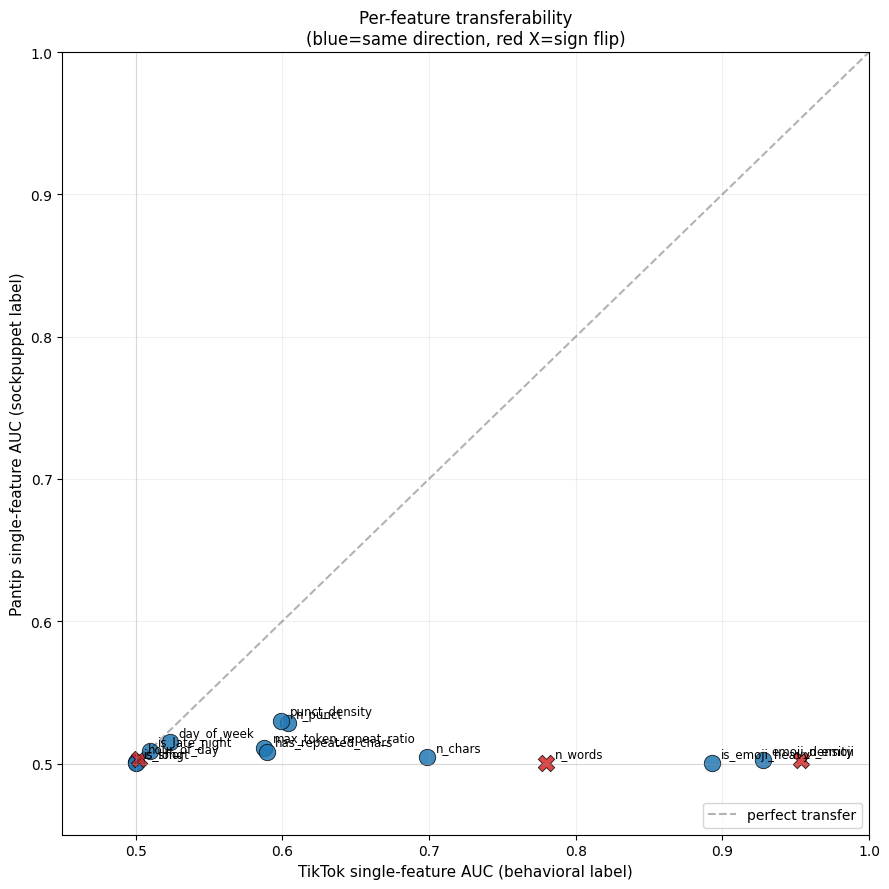

Saved -> transferability_scatter.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 9))

# Diagonal reference
ax.plot([0.5, 1.0], [0.5, 1.0], 'k--', alpha=0.3, label='perfect transfer')
ax.axhline(0.5, color='gray', alpha=0.2, linewidth=0.8)
ax.axvline(0.5, color='gray', alpha=0.2, linewidth=0.8)

# Points: rectified AUC, marker shape encodes sign-flip
for _, row in pf.iterrows():
    marker = 'X' if row['sign_flip'] else 'o'
    color = '#d62728' if row['sign_flip'] else '#1f77b4'
    ax.scatter(row['tt_auc_eff'], row['pt_auc_eff'],
               s=140, marker=marker, color=color,
               edgecolor='black', linewidth=0.6, alpha=0.85)
    ax.annotate(row['feature'], (row['tt_auc_eff'], row['pt_auc_eff']),
                xytext=(6, 4), textcoords='offset points', fontsize=8.5)

ax.set_xlabel('TikTok single-feature AUC (behavioral label)', fontsize=11)
ax.set_ylabel('Pantip single-feature AUC (sockpuppet label)', fontsize=11)
ax.set_title('Per-feature transferability\n(blue=same direction, red X=sign flip)',
             fontsize=12)
ax.set_xlim(0.45, 1.0)
ax.set_ylim(0.45, 1.0)
ax.grid(alpha=0.2)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(SCATTER, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {SCATTER}')

## Reading guide

**Within-domain F1 (Blocks 1 & 2)** — these are the ceilings. If TikTok within-domain F1 is, say, 0.7 and Pantip within-domain F1 is 0.6, then zero-shot transfer F1 below these is the gap you're characterizing.

**Block 3 vs Block 4 comparison** — if Block 3 (behavioral label) outperforms Block 4 (full label), the relabeling exercise was justified: removing Filipino-lexicon-triggered positives improved generalization. If Block 4 outperforms, the lexicon signal was incidentally capturing universal patterns.

**Scatter plot** — count the points:
- Upper-right cluster (both AUC > 0.65): transferable features. These define the universal signal.
- Spread along x-axis only: TikTok-specific.
- Spread along y-axis only: Pantip-specific.
- Red X markers: features where the direction of effect flips. These are actively harmful for transfer; a model trained on one platform will predict *wrong* on the other.

**Story to tell in the thesis chapter:**

If the scatter shows few diagonal points (likely given the discrimination diagnostic), the conclusion is: *behavioral feature transfer across TikTok and Pantip is limited not by feature engineering but by phenomenon divergence — amplifiers and sockpuppets are behaviorally distinct constructs.* This is the publishable finding.